# Field + AD/FD gradient demo for position.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import mitsuba as mi
import drjit as dr

from example_utils import (
    compute_field, compute_ad_gradient, compute_fd_gradient,
    plot_three_panel, print_gradient_summary, prepare_gradient_visualization, get_edges
)

jitc_llvm_init(): LLVM API initialization failed ..


## Parameters

In [2]:
grid_size = 512
freq = 1e9
tx_pos = (-5.0, 5.0, 1.5)
range_x, range_y = (-8, 8), (-8, 8)
center_vals = (0.0, 0.0, 2.0)
size = 4.0
n_rays = 1000000
max_reflections = 1
reflection_coef = 1.0

print(f"Grid: {grid_size}x{grid_size}, Freq: {freq/1e9:.1f} GHz")
print(f"Cube center: {center_vals}, TX: {tx_pos}")

Grid: 512x512, Freq: 1.0 GHz
Cube center: (0.0, 0.0, 2.0), TX: (-5.0, 5.0, 1.5)


## Compute Gradients

In [3]:
# AD gradient: d/d(center_x)
def ad_setup():
    center = mi.Point3f(*[float(v) for v in center_vals])
    dr.enable_grad(center)
    dr.set_grad(center, mi.Vector3f(1.0, 0.0, 0.0))
    return compute_field(center, size, freq, tx_pos, range_x, range_y, grid_size,
                         n_rays=n_rays, max_reflections=max_reflections,
                         reflection_coef=reflection_coef)

print("[1] Computing AD gradient |da_tot/dx|...")
result_ad, scene_ad, grad_ad_mag = compute_ad_gradient(ad_setup, grid_size)
print(f"    sum = {np.sum(grad_ad_mag):.2f}")

# FD gradient: (f(x+delta) - f(x)) / delta
def fd_base():
    return compute_field(center_vals, size, freq, tx_pos, range_x, range_y, grid_size,
                         n_rays=n_rays, max_reflections=max_reflections,
                         reflection_coef=reflection_coef)

def fd_perturbed():
    c = (center_vals[0] + 0.01, center_vals[1], center_vals[2])
    return compute_field(c, size, freq, tx_pos, range_x, range_y, grid_size,
                         n_rays=n_rays, max_reflections=max_reflections,
                         reflection_coef=reflection_coef)

print("\n[2] Computing FD gradient |da_tot/dx|...")
result_fd, scene_fd, grad_fd_mag = compute_fd_gradient(fd_base, fd_perturbed, grid_size)
print(f"    sum = {np.sum(grad_fd_mag):.2f}")

[1] Computing AD gradient |da_tot/dx|...
    sum = 2881.36

[2] Computing FD gradient |da_tot/dx|...
    sum = 2875.95


## Visualize

[OK] Figure saved to figures/demo.png

Summary: |da_tot/dx|
  AD sum: 2881.36
  FD sum: 2875.95
  Difference: 5.41
  Relative diff: 0.19%

[OK] Gradients are working!


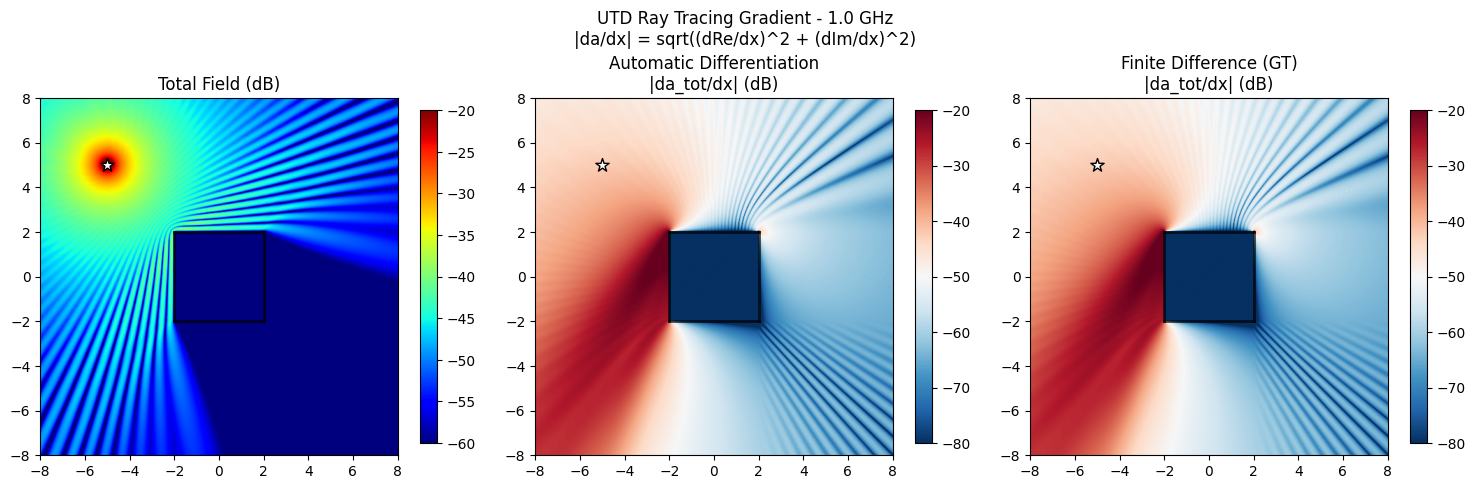

In [4]:
field_db, grad_ad_db, grad_fd_db = prepare_gradient_visualization(
    result_fd, grad_ad_mag, grad_fd_mag, grid_size)
edges = get_edges(scene_fd, result_fd)

plot_three_panel(
    field_db, grad_ad_db, grad_fd_db, edges, tx_pos, range_x, range_y,
    titles=['Total Field (dB)',
            'Automatic Differentiation\n|da_tot/dx| (dB)',
            'Finite Difference (GT)\n|da_tot/dx| (dB)'],
    suptitle=f'UTD Ray Tracing Gradient - {freq/1e9:.1f} GHz\n'
             f'|da/dx| = sqrt((dRe/dx)^2 + (dIm/dx)^2)',
    save_path='figures/demo.png',
    grad_vmin=-80, grad_vmax=-20, fontsize=12
)
print_gradient_summary('|da_tot/dx|', grad_ad_mag, grad_fd_mag)
plt.show()